**ANÁLISIS EXPLORATORIO DE DATOS EDA**

El objetivo del análisis es comprender la estructura y comportamiento de los datos de clientes antes de desarrollar el modelo predictivo de conversión.

In [3]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
df.head()

,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,...,es_nuevo_cliente,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion,objetivo
0,1,202601,26,42120.349663,0.367310,139,2,40949.765573,67,professional,...,False,False,222,10,9.898223,android,21,True,67,0
1,2,202601,56,89837.390440,0.338092,29,2,35233.622561,304,manager,...,False,False,58,2,9.311922,ios,20,True,304,0
2,3,202601,34,45951.715455,0.444587,21,2,39486.902998,220,clerical,...,False,False,8,6,12.188249,android,12,False,220,0
3,4,202601,62,54673.148516,0.243261,43,2,300.000000,110,manual,...,False,False,119,9,10.459796,ios,20,False,110,0
4,5,202601,37,100239.135609,0.230946,113,1,32066.808006,247,professional,...,False,False,25,6,36.502645,ios,13,False,247,1


In [5]:
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

Cantidad de filas: 110100
Cantidad de columnas: 25


In [6]:
df.columns

Index(['id_cliente', 'mes', 'edad', 'ingresos', 'ratio_deuda_ingresos',
       'antiguedad_cuenta_meses', 'numero_productos', 'saldo_promedio',
       'dias_ultima_transaccion', 'ocupacion', 'region', 'canal_adquisicion',
       'banda_riesgo', 'tiene_tarjeta_credito', 'activo_movil',
       'es_nuevo_cliente', 'tiene_prestamo', 'antiguedad_direccion_meses',
       'visitas_web_ultimos_90_dias', 'distancia_sucursal_km',
       'dispositivo_principal', 'dia_preferido_pago', 'tiene_seguro',
       'dias_ultima_interaccion', 'objetivo'],
      dtype='object')

In [7]:
for i, columna in enumerate(df.columns, start=1):
    print(i, "-", columna)

1 - id_cliente
2 - mes
3 - edad
4 - ingresos
5 - ratio_deuda_ingresos
6 - antiguedad_cuenta_meses
7 - numero_productos
8 - saldo_promedio
9 - dias_ultima_transaccion
10 - ocupacion
11 - region
12 - canal_adquisicion
13 - banda_riesgo
14 - tiene_tarjeta_credito
15 - activo_movil
16 - es_nuevo_cliente
17 - tiene_prestamo
18 - antiguedad_direccion_meses
19 - visitas_web_ultimos_90_dias
20 - distancia_sucursal_km
21 - dispositivo_principal
22 - dia_preferido_pago
23 - tiene_seguro
24 - dias_ultima_interaccion
25 - objetivo


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110100 entries, 0 to 110099
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_cliente                   110100 non-null  int64  
 1   mes                          110100 non-null  int64  
 2   edad                         110100 non-null  int64  
 3   ingresos                     110100 non-null  float64
 4   ratio_deuda_ingresos         110100 non-null  float64
 5   antiguedad_cuenta_meses      110100 non-null  int64  
 6   numero_productos             110100 non-null  int64  
 7   saldo_promedio               110100 non-null  float64
 8   dias_ultima_transaccion      110100 non-null  int64  
 9   ocupacion                    110100 non-null  object 
 10  region                       110100 non-null  object 
 11  canal_adquisicion            110100 non-null  object 
 12  banda_riesgo                 110100 non-null  object 
 13 

In [9]:
# Variables numéricas

variables_numericas = [
    "edad",
    "ingresos",
    "ratio_deuda_ingresos",
    "antiguedad_cuenta_meses",
    "numero_productos",
    "saldo_promedio",
    "dias_ultima_transaccion",
    "antiguedad_direccion_meses",
    "visitas_web_ultimos_90_dias",
    "distancia_sucursal_km",
    "dia_preferido_pago",
    "dias_ultima_interaccion"
]

# Variables categóricas

variables_categoricas = [
    "ocupacion",
    "region",
    "canal_adquisicion",
    "banda_riesgo",
    "dispositivo_principal"
]

# Variables booleanas

variables_booleanas = [
    "tiene_tarjeta_credito",
    "activo_movil",
    "es_nuevo_cliente",
    "tiene_prestamo",
    "tiene_seguro"
]

print("Variables numéricas:", len(variables_numericas))
print("Variables categóricas:", len(variables_categoricas))
print("Variables booleanas:", len(variables_booleanas))

Variables numéricas: 12
Variables categóricas: 5
Variables booleanas: 5


In [12]:
faltantes = df.isnull().sum()

tabla_faltantes = pd.DataFrame({
    "Variable": faltantes.index,
    "Valores faltantes": faltantes.values
})

tabla_faltantes

,Variable,Valores faltantes
0,id_cliente,0
1,mes,0
2,edad,0
3,ingresos,0
4,ratio_deuda_ingresos,0
5,antiguedad_cuenta_meses,0
6,numero_productos,0
7,saldo_promedio,0
8,dias_ultima_transaccion,0
9,ocupacion,0


In [13]:
print("Total de valores faltantes:", df.isnull().sum().sum())

Total de valores faltantes: 0


In [15]:
duplicados = df.duplicated().sum()

print("Cantidad de filas duplicadas:", duplicados)

Cantidad de filas duplicadas: 0


In [16]:
duplicados_cliente_mes = df.duplicated(
    subset=["id_cliente", "mes"]
).sum()

print("Clientes repetidos dentro del mismo mes:", duplicados_cliente_mes)

Clientes repetidos dentro del mismo mes: 0


In [17]:
clientes_unicos = df["id_cliente"].nunique()

print("Cantidad de clientes únicos:", clientes_unicos)

Cantidad de clientes únicos: 24628


In [18]:
print("Cantidad de registros:", len(df))
print("Cantidad de clientes únicos:", df["id_cliente"].nunique())

Cantidad de registros: 110100
Cantidad de clientes únicos: 24628


cuantos meses aparece cada cliente


In [19]:
meses_por_cliente = (
    df.groupby("id_cliente")["mes"]
      .nunique()
)

meses_por_cliente.describe()

,mes
count,24628.000000
mean,4.470521
std,3.171648
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,11.000000


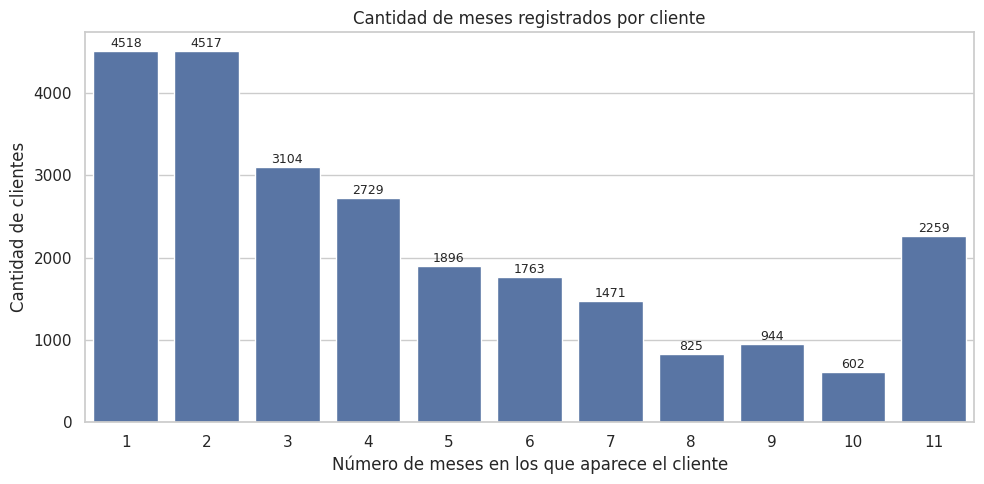

In [21]:
# Contamos cuántos clientes aparecen en 1 mes, 2 meses, 3 meses, etc.
conteo_meses = meses_por_cliente.value_counts().sort_index()

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=conteo_meses.index,
    y=conteo_meses.values
)

plt.title("Cantidad de meses registrados por cliente")
plt.xlabel("Número de meses en los que aparece el cliente")
plt.ylabel("Cantidad de clientes")

# Mostrar el número encima de cada barra
for i, valor in enumerate(conteo_meses.values):
    ax.text(
        i,
        valor + 50,
        str(valor),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [23]:
resumen_numericas = df[variables_numericas].describe().T

resumen_numericas

,count,mean,std,min,25%,50%,75%,max
edad,110100.0,46.358955,14.347644,22.000000,34.000000,46.000000,59.000000,71.000000
ingresos,110100.0,65162.459850,21740.994996,18000.000000,50148.620538,64858.011517,79838.143483,145700.072671
ratio_deuda_ingresos,110100.0,0.329427,0.166854,0.020000,0.201478,0.310624,0.438466,0.950000
antiguedad_cuenta_meses,110100.0,88.898438,51.523654,1.000000,44.000000,88.000000,133.000000,179.000000
numero_productos,110100.0,1.923106,1.073968,1.000000,1.000000,2.000000,3.000000,5.000000
saldo_promedio,110100.0,26294.246319,16035.584959,300.000000,14487.427386,25692.024597,37264.060444,90000.000000
dias_ultima_transaccion,110100.0,190.245023,104.950746,1.000000,101.000000,194.000000,282.000000,364.000000
antiguedad_direccion_meses,110100.0,119.959246,68.794901,1.000000,61.000000,120.000000,179.000000,239.000000
visitas_web_ultimos_90_dias,110100.0,8.012035,2.807439,0.000000,6.000000,8.000000,10.000000,26.000000
distancia_sucursal_km,110100.0,10.157805,9.198803,0.212526,4.330854,7.487017,12.717978,80.000000


In [24]:
df["objetivo"].value_counts()

,count
objetivo,
0,93533
1,16567


In [25]:
df["objetivo"].value_counts(normalize=True) * 100

,proportion
objetivo,
0,84.95277
1,15.04723


In [26]:
resumen_objetivo = pd.DataFrame({
    "Cantidad": df["objetivo"].value_counts(),
    "Porcentaje": df["objetivo"].value_counts(normalize=True) * 100
})

resumen_objetivo

,Cantidad,Porcentaje
objetivo,,
0,93533,84.95277
1,16567,15.04723


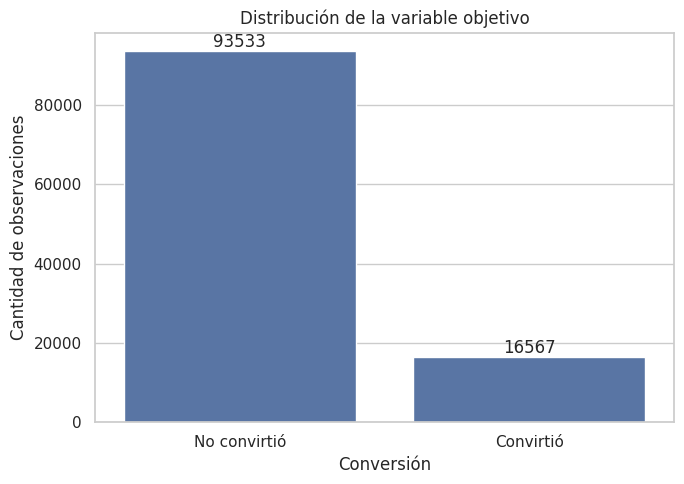

In [27]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="objetivo"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Conversión")
plt.ylabel("Cantidad de observaciones")

plt.xticks(
    [0,1],
    ["No convirtió", "Convirtió"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

ANALIZAR LA EDAD
Usamos todas las filas del dataset. Como un mismo cliente puede aparecer en varios meses, ese cliente se cuenta varias

In [29]:
# Crear rangos de edad
df["rango_edad"] = pd.cut(
    df["edad"],
    bins=[20, 30, 40, 50, 60, 70, 80],
    labels=[
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71-80"
    ],
    include_lowest=True
)

# Contar clientes/observaciones por rango
conteo_edades = (
    df["rango_edad"]
    .value_counts()
    .sort_index()
)

conteo_edades

,count
rango_edad,
21-30,19929
31-40,22199
41-50,22143
51-60,22254
61-70,21457
71-80,2118


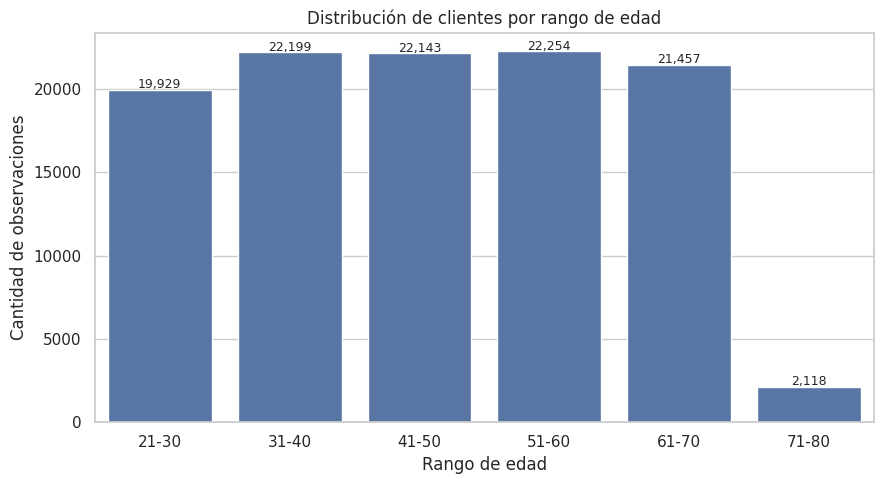

In [30]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=conteo_edades.index,
    y=conteo_edades.values
)

plt.title("Distribución de clientes por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de observaciones")

# Valores encima de las barras
for i, valor in enumerate(conteo_edades.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

ANALISIS DE EDAD
primero dejamos una sola fila por cliente

In [31]:
clientes_unicos_edad = (
    df.sort_values("mes")
      .drop_duplicates(
          subset="id_cliente",
          keep="last"
      )
)

In [32]:
clientes_unicos_edad["rango_edad"] = pd.cut(
    clientes_unicos_edad["edad"],
    bins=[20, 30, 40, 50, 60, 70, 80],
    labels=[
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71-80"
    ],
    include_lowest=True
)

conteo_edades_clientes = (
    clientes_unicos_edad["rango_edad"]
    .value_counts()
    .sort_index()
)

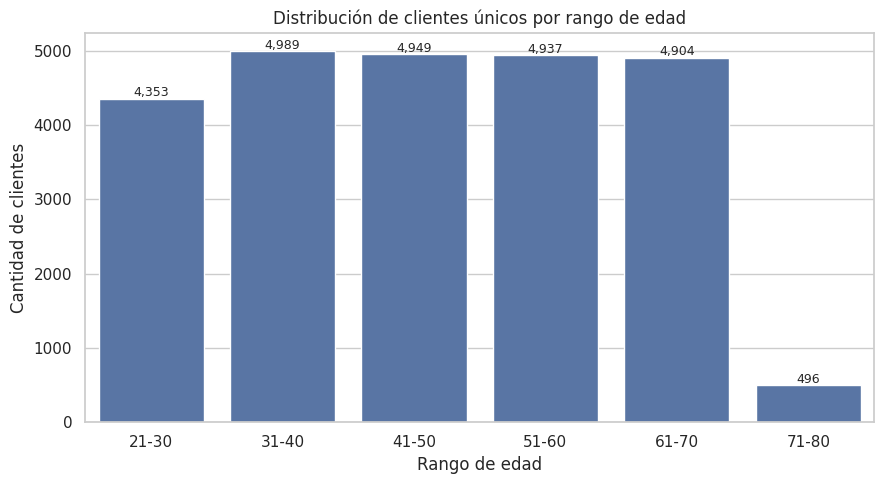

In [33]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=conteo_edades_clientes.index,
    y=conteo_edades_clientes.values
)

plt.title("Distribución de clientes únicos por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de clientes")

for i, valor in enumerate(conteo_edades_clientes.values):
    ax.text(
        i,
        valor + 30,
        f"{valor:,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Ingresos**

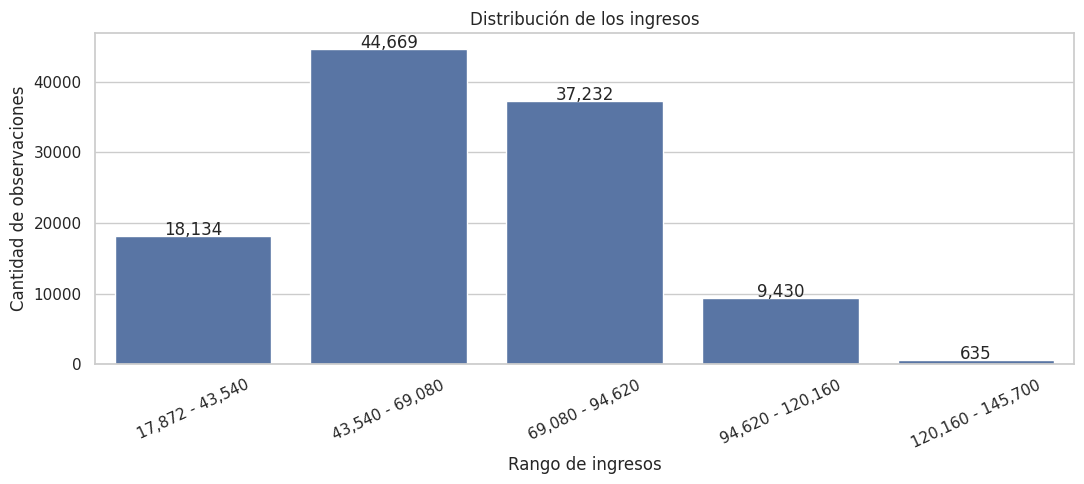

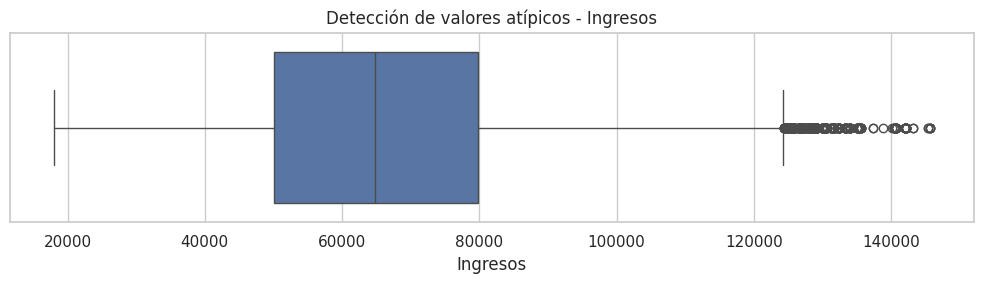

In [56]:
# ============================================
# INGRESOS
# ============================================

# Crear rangos automáticos pero con etiquetas legibles
grupos_ingresos, limites_ingresos = pd.cut(
    df["ingresos"],
    bins=5,
    retbins=True
)

etiquetas_ingresos = []

for i in range(len(limites_ingresos) - 1):
    etiquetas_ingresos.append(
        f"{limites_ingresos[i]:,.0f} - {limites_ingresos[i+1]:,.0f}"
    )

df["rango_ingresos"] = pd.cut(
    df["ingresos"],
    bins=limites_ingresos,
    labels=etiquetas_ingresos,
    include_lowest=True
)

conteo_ingresos = (
    df["rango_ingresos"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1: Distribución
plt.figure(figsize=(11,5))

ax = sns.barplot(
    x=conteo_ingresos.index,
    y=conteo_ingresos.values
)

plt.title("Distribución de los ingresos")
plt.xlabel("Rango de ingresos")
plt.ylabel("Cantidad de observaciones")

plt.xticks(rotation=25)

for i, valor in enumerate(conteo_ingresos.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2: Boxplot
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="ingresos"
)

plt.title("Detección de valores atípicos - Ingresos")
plt.xlabel("Ingresos")

plt.tight_layout()
plt.show()

**RADIO DEUDA(q tan grande es su deuda de acuerdo a lo q gana):0.20 ->significa que la deuda representa aproximadamente el 20 % de sus ingresos.**

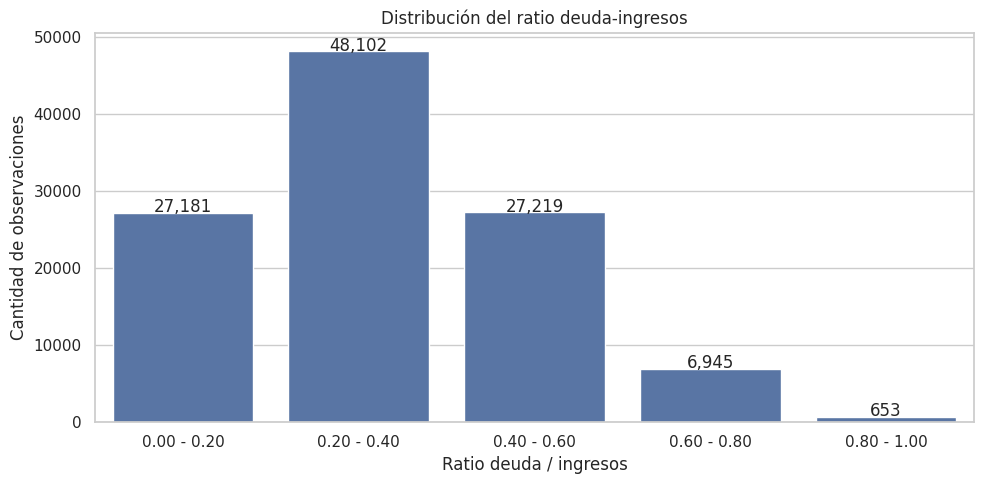

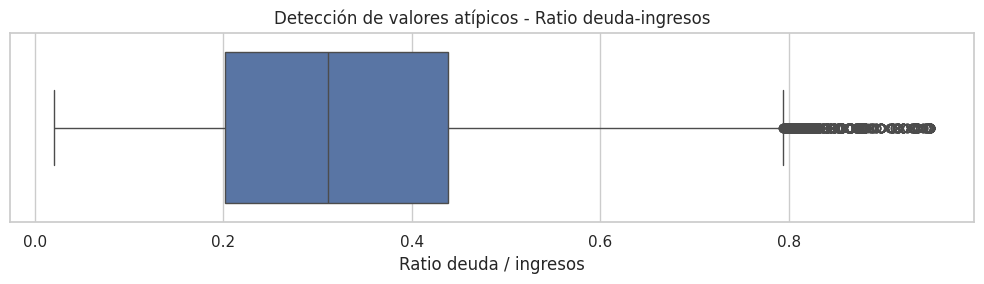

In [57]:
# ============================================
# RATIO DEUDA - INGRESOS
# ============================================

bins_ratio = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

labels_ratio = [
    "0.00 - 0.20",
    "0.20 - 0.40",
    "0.40 - 0.60",
    "0.60 - 0.80",
    "0.80 - 1.00"
]

df["rango_ratio_deuda"] = pd.cut(
    df["ratio_deuda_ingresos"],
    bins=bins_ratio,
    labels=labels_ratio,
    include_lowest=True
)

conteo_ratio = (
    df["rango_ratio_deuda"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=conteo_ratio.index,
    y=conteo_ratio.values
)

plt.title("Distribución del ratio deuda-ingresos")
plt.xlabel("Ratio deuda / ingresos")
plt.ylabel("Cantidad de observaciones")

for i, valor in enumerate(conteo_ratio.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="ratio_deuda_ingresos"
)

plt.title("Detección de valores atípicos - Ratio deuda-ingresos")
plt.xlabel("Ratio deuda / ingresos")

plt.tight_layout()
plt.show()

 **Antiguedad de cuenta**

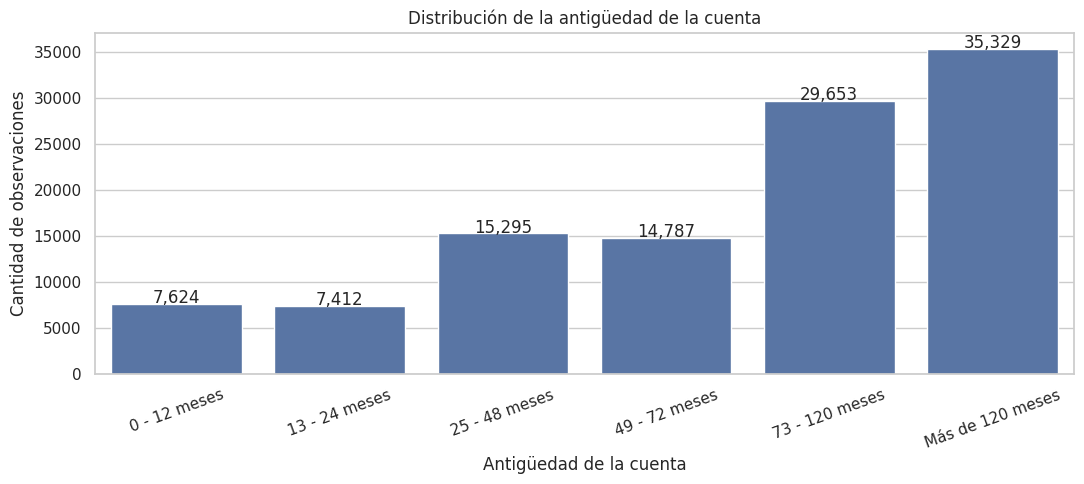

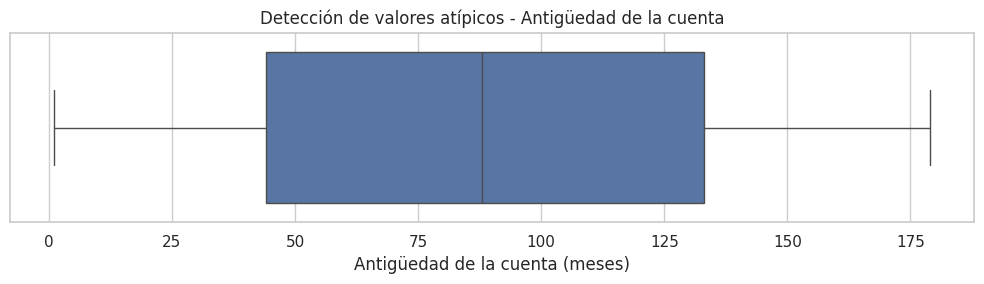

In [58]:
# ============================================
# ANTIGÜEDAD DE LA CUENTA
# ============================================

bins_antiguedad = [
    0,
    12,
    24,
    48,
    72,
    120,
    df["antiguedad_cuenta_meses"].max() + 1
]

labels_antiguedad = [
    "0 - 12 meses",
    "13 - 24 meses",
    "25 - 48 meses",
    "49 - 72 meses",
    "73 - 120 meses",
    "Más de 120 meses"
]

df["rango_antiguedad_cuenta"] = pd.cut(
    df["antiguedad_cuenta_meses"],
    bins=bins_antiguedad,
    labels=labels_antiguedad,
    include_lowest=True
)

conteo_antiguedad = (
    df["rango_antiguedad_cuenta"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(11,5))

ax = sns.barplot(
    x=conteo_antiguedad.index,
    y=conteo_antiguedad.values
)

plt.title("Distribución de la antigüedad de la cuenta")
plt.xlabel("Antigüedad de la cuenta")
plt.ylabel("Cantidad de observaciones")

plt.xticks(rotation=20)

for i, valor in enumerate(conteo_antiguedad.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="antiguedad_cuenta_meses"
)

plt.title("Detección de valores atípicos - Antigüedad de la cuenta")
plt.xlabel("Antigüedad de la cuenta (meses)")

plt.tight_layout()
plt.show()

**Numero de productos**

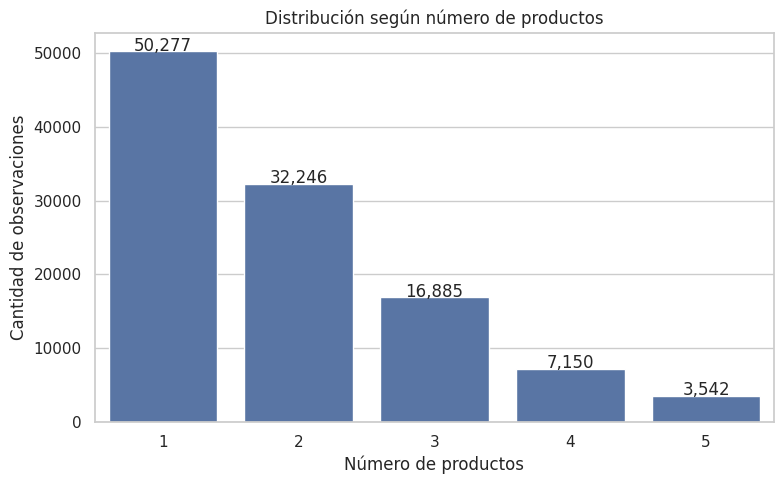

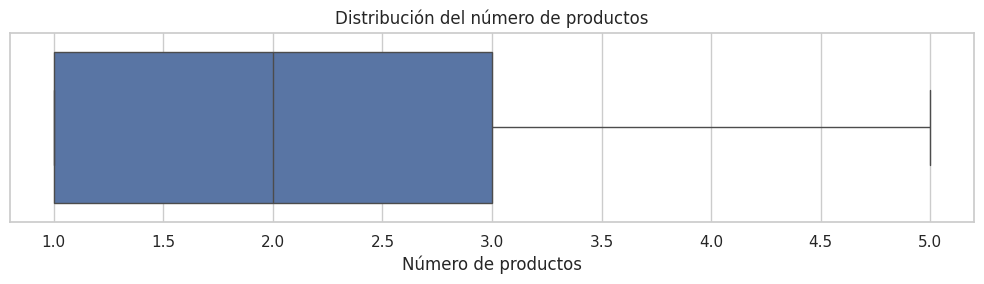

In [59]:
# ============================================
# NÚMERO DE PRODUCTOS
# ============================================

conteo_productos = (
    df["numero_productos"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=conteo_productos.index,
    y=conteo_productos.values
)

plt.title("Distribución según número de productos")
plt.xlabel("Número de productos")
plt.ylabel("Cantidad de observaciones")

for i, valor in enumerate(conteo_productos.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="numero_productos"
)

plt.title("Distribución del número de productos")
plt.xlabel("Número de productos")

plt.tight_layout()
plt.show()

**Saldo promedio**

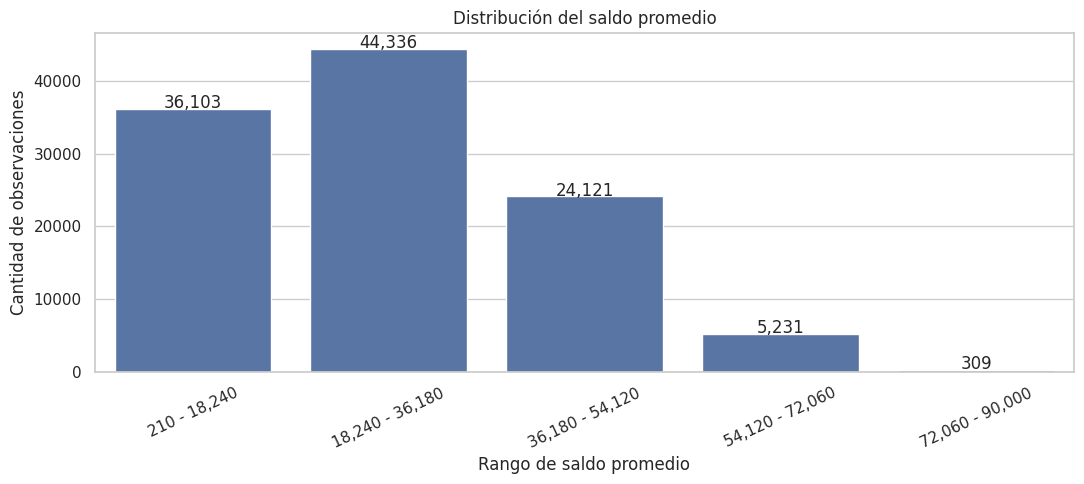

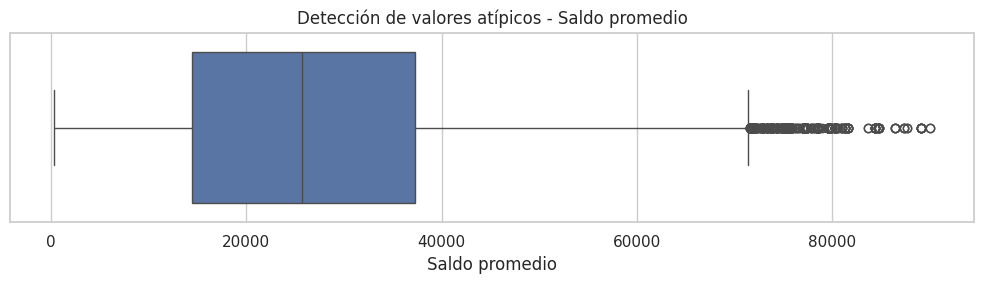

In [60]:
# ============================================
# SALDO PROMEDIO
# ============================================

grupos_saldo, limites_saldo = pd.cut(
    df["saldo_promedio"],
    bins=5,
    retbins=True
)

etiquetas_saldo = []

for i in range(len(limites_saldo) - 1):
    etiquetas_saldo.append(
        f"{limites_saldo[i]:,.0f} - {limites_saldo[i+1]:,.0f}"
    )

df["rango_saldo"] = pd.cut(
    df["saldo_promedio"],
    bins=limites_saldo,
    labels=etiquetas_saldo,
    include_lowest=True
)

conteo_saldo = (
    df["rango_saldo"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(11,5))

ax = sns.barplot(
    x=conteo_saldo.index,
    y=conteo_saldo.values
)

plt.title("Distribución del saldo promedio")
plt.xlabel("Rango de saldo promedio")
plt.ylabel("Cantidad de observaciones")

plt.xticks(rotation=25)

for i, valor in enumerate(conteo_saldo.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="saldo_promedio"
)

plt.title("Detección de valores atípicos - Saldo promedio")
plt.xlabel("Saldo promedio")

plt.tight_layout()
plt.show()

**Dias de la ultima transaccion**

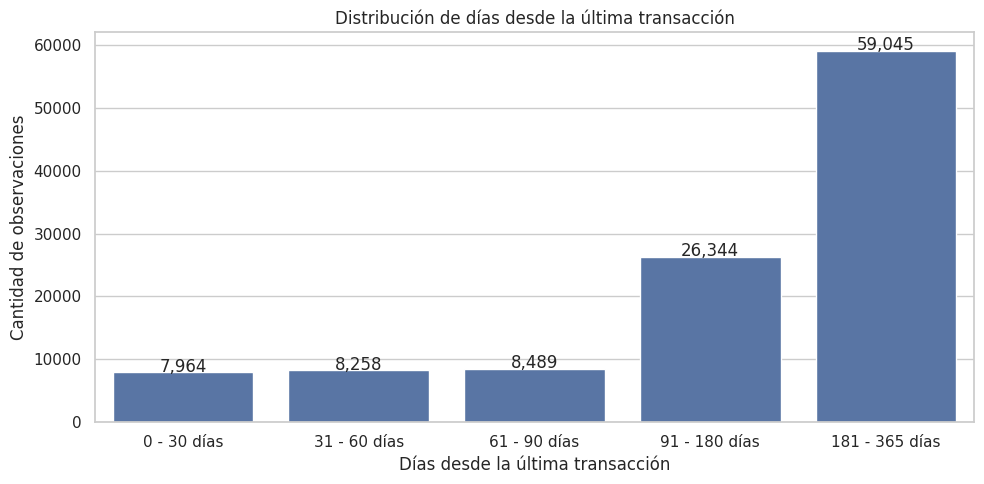

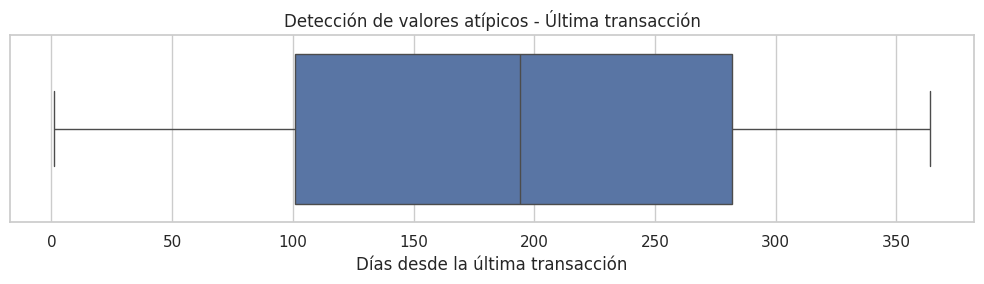

In [61]:
# ============================================
# DÍAS DESDE LA ÚLTIMA TRANSACCIÓN
# ============================================

bins_transaccion = [0, 30, 60, 90, 180, 365]

labels_transaccion = [
    "0 - 30 días",
    "31 - 60 días",
    "61 - 90 días",
    "91 - 180 días",
    "181 - 365 días"
]

df["rango_ultima_transaccion"] = pd.cut(
    df["dias_ultima_transaccion"],
    bins=bins_transaccion,
    labels=labels_transaccion,
    include_lowest=True
)

conteo_transaccion = (
    df["rango_ultima_transaccion"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=conteo_transaccion.index,
    y=conteo_transaccion.values
)

plt.title("Distribución de días desde la última transacción")
plt.xlabel("Días desde la última transacción")
plt.ylabel("Cantidad de observaciones")

for i, valor in enumerate(conteo_transaccion.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="dias_ultima_transaccion"
)

plt.title("Detección de valores atípicos - Última transacción")
plt.xlabel("Días desde la última transacción")

plt.tight_layout()
plt.show()

**Antiguedad de direccion**

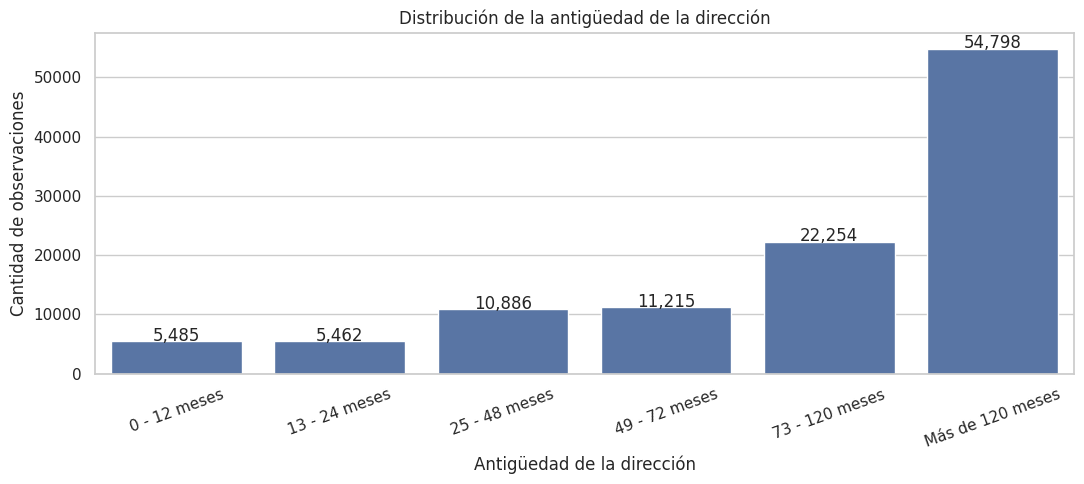

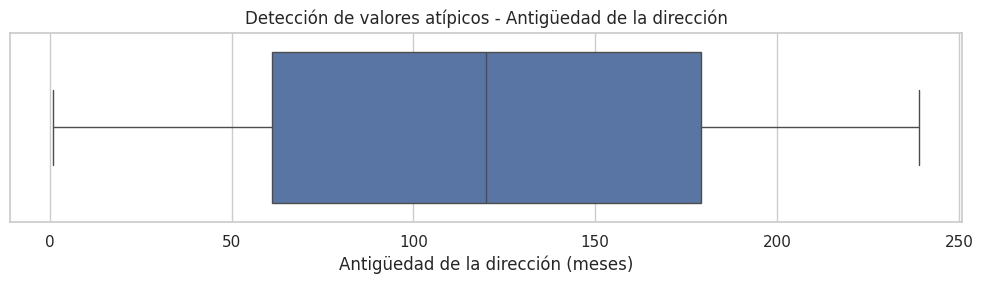

In [62]:
# ============================================
# ANTIGÜEDAD DE LA DIRECCIÓN
# ============================================

bins_direccion = [
    0,
    12,
    24,
    48,
    72,
    120,
    df["antiguedad_direccion_meses"].max() + 1
]

labels_direccion = [
    "0 - 12 meses",
    "13 - 24 meses",
    "25 - 48 meses",
    "49 - 72 meses",
    "73 - 120 meses",
    "Más de 120 meses"
]

df["rango_antiguedad_direccion"] = pd.cut(
    df["antiguedad_direccion_meses"],
    bins=bins_direccion,
    labels=labels_direccion,
    include_lowest=True
)

conteo_direccion = (
    df["rango_antiguedad_direccion"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(11,5))

ax = sns.barplot(
    x=conteo_direccion.index,
    y=conteo_direccion.values
)

plt.title("Distribución de la antigüedad de la dirección")
plt.xlabel("Antigüedad de la dirección")
plt.ylabel("Cantidad de observaciones")

plt.xticks(rotation=20)

for i, valor in enumerate(conteo_direccion.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="antiguedad_direccion_meses"
)

plt.title("Detección de valores atípicos - Antigüedad de la dirección")
plt.xlabel("Antigüedad de la dirección (meses)")

plt.tight_layout()
plt.show()

**Visitas web últimos 90 días**

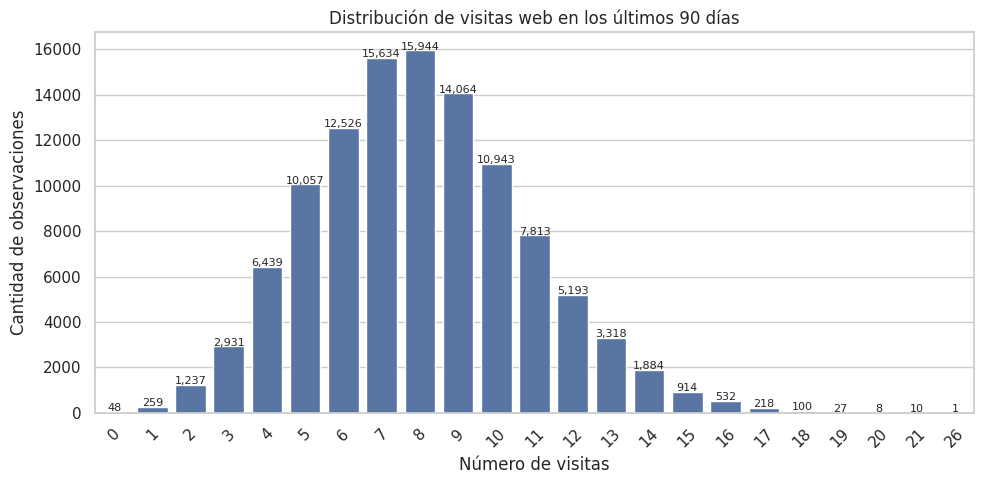

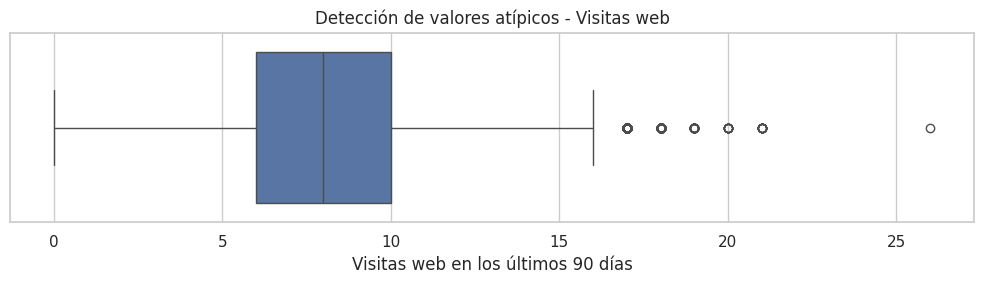

In [63]:
# ============================================
# VISITAS WEB ÚLTIMOS 90 DÍAS
# ============================================

conteo_visitas = (
    df["visitas_web_ultimos_90_dias"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=conteo_visitas.index,
    y=conteo_visitas.values
)

plt.title("Distribución de visitas web en los últimos 90 días")
plt.xlabel("Número de visitas")
plt.ylabel("Cantidad de observaciones")

plt.xticks(rotation=45)

for i, valor in enumerate(conteo_visitas.values):
    ax.text(
        i,
        valor + 30,
        f"{valor:,}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="visitas_web_ultimos_90_dias"
)

plt.title("Detección de valores atípicos - Visitas web")
plt.xlabel("Visitas web en los últimos 90 días")

plt.tight_layout()
plt.show()

**Distancia a al sucursal**

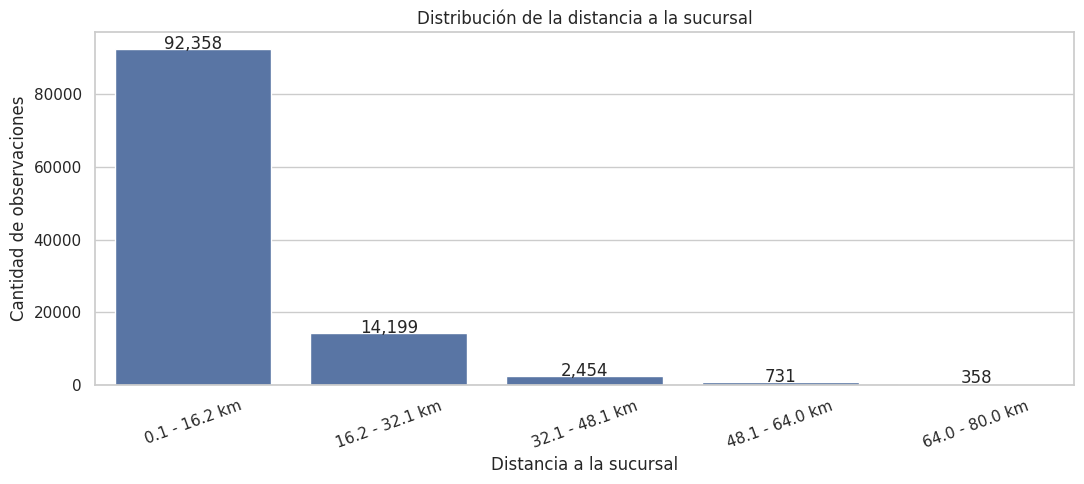

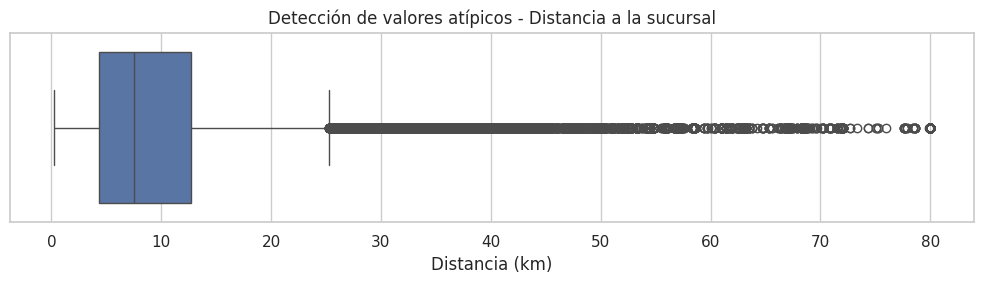

In [64]:
# ============================================
# DISTANCIA A LA SUCURSAL
# ============================================

grupos_distancia, limites_distancia = pd.cut(
    df["distancia_sucursal_km"],
    bins=5,
    retbins=True
)

etiquetas_distancia = []

for i in range(len(limites_distancia) - 1):
    etiquetas_distancia.append(
        f"{limites_distancia[i]:.1f} - {limites_distancia[i+1]:.1f} km"
    )

df["rango_distancia"] = pd.cut(
    df["distancia_sucursal_km"],
    bins=limites_distancia,
    labels=etiquetas_distancia,
    include_lowest=True
)

conteo_distancia = (
    df["rango_distancia"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(11,5))

ax = sns.barplot(
    x=conteo_distancia.index,
    y=conteo_distancia.values
)

plt.title("Distribución de la distancia a la sucursal")
plt.xlabel("Distancia a la sucursal")
plt.ylabel("Cantidad de observaciones")

plt.xticks(rotation=20)

for i, valor in enumerate(conteo_distancia.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="distancia_sucursal_km"
)

plt.title("Detección de valores atípicos - Distancia a la sucursal")
plt.xlabel("Distancia (km)")

plt.tight_layout()
plt.show()

**Dia preferido de pago**

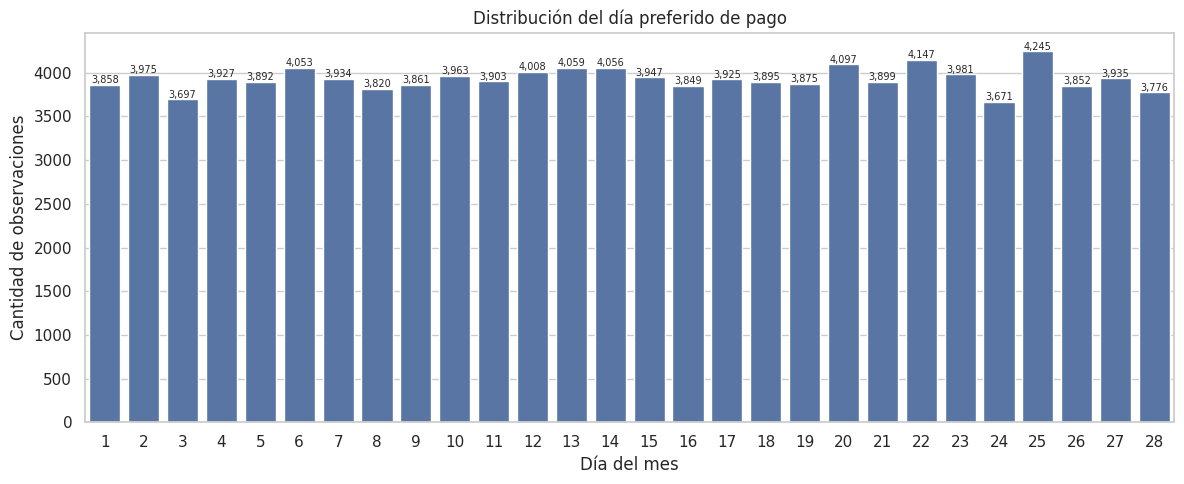

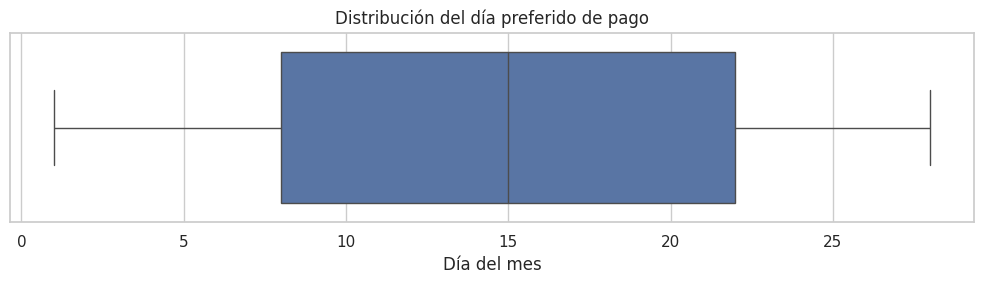

In [65]:
# ============================================
# DÍA PREFERIDO DE PAGO
# ============================================

conteo_pago = (
    df["dia_preferido_pago"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(12,5))

ax = sns.barplot(
    x=conteo_pago.index,
    y=conteo_pago.values
)

plt.title("Distribución del día preferido de pago")
plt.xlabel("Día del mes")
plt.ylabel("Cantidad de observaciones")

for i, valor in enumerate(conteo_pago.values):
    ax.text(
        i,
        valor + 20,
        f"{valor:,}",
        ha="center",
        fontsize=7
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="dia_preferido_pago"
)

plt.title("Distribución del día preferido de pago")
plt.xlabel("Día del mes")

plt.tight_layout()
plt.show()

**Días desde la última interacción**

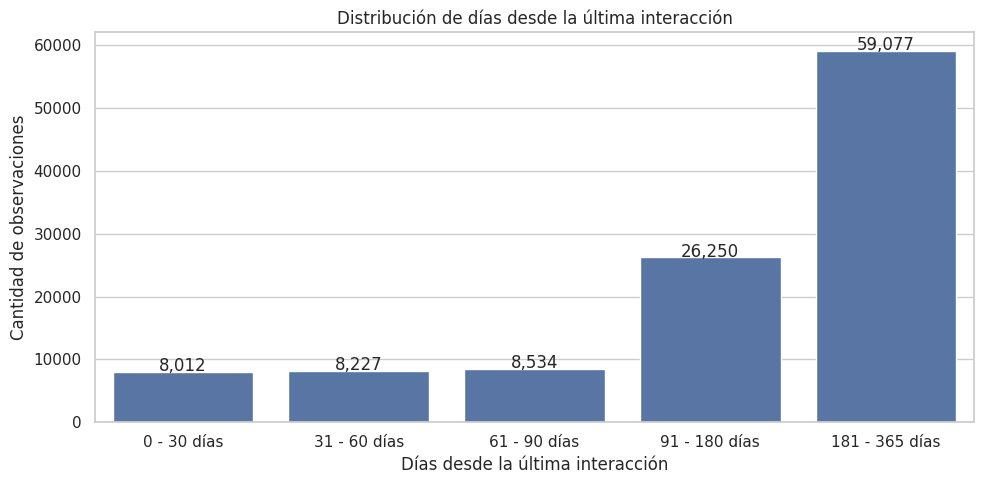

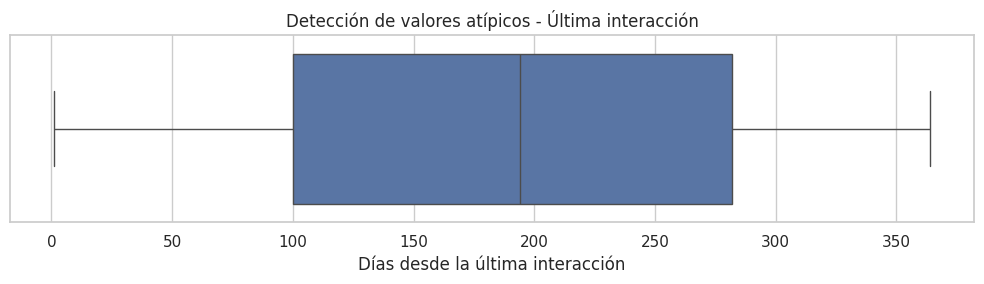

In [66]:
# ============================================
# DÍAS DESDE LA ÚLTIMA INTERACCIÓN
# ============================================

bins_interaccion = [0, 30, 60, 90, 180, 365]

labels_interaccion = [
    "0 - 30 días",
    "31 - 60 días",
    "61 - 90 días",
    "91 - 180 días",
    "181 - 365 días"
]

df["rango_ultima_interaccion"] = pd.cut(
    df["dias_ultima_interaccion"],
    bins=bins_interaccion,
    labels=labels_interaccion,
    include_lowest=True
)

conteo_interaccion = (
    df["rango_ultima_interaccion"]
    .value_counts()
    .sort_index()
)

# GRÁFICO 1
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=conteo_interaccion.index,
    y=conteo_interaccion.values
)

plt.title("Distribución de días desde la última interacción")
plt.xlabel("Días desde la última interacción")
plt.ylabel("Cantidad de observaciones")

for i, valor in enumerate(conteo_interaccion.values):
    ax.text(
        i,
        valor + 100,
        f"{valor:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# GRÁFICO 2
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="dias_ultima_interaccion"
)

plt.title("Detección de valores atípicos - Última interacción")
plt.xlabel("Días desde la última interacción")

plt.tight_layout()
plt.show()

**Categoricas**

In [67]:
variables_categoricas = [
    "ocupacion",
    "region",
    "canal_adquisicion",
    "banda_riesgo",
    "dispositivo_principal"
]

In [68]:
def grafico_categoria(columna, titulo):

    conteo = df[columna].value_counts()

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        x=conteo.index,
        y=conteo.values
    )

    plt.title(titulo)
    plt.xlabel("")
    plt.ylabel("Cantidad de observaciones")

    plt.xticks(rotation=25)

    for i, valor in enumerate(conteo.values):
        ax.text(
            i,
            valor + 50,
            f"{valor:,}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

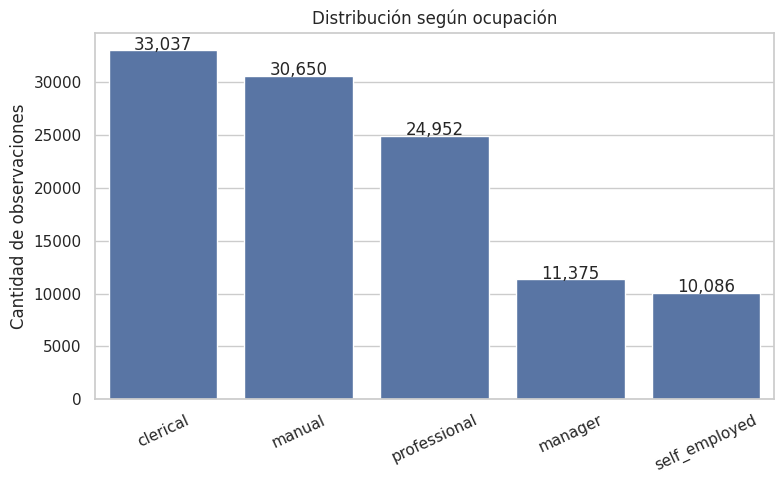

In [69]:
grafico_categoria(
    "ocupacion",
    "Distribución según ocupación"
)

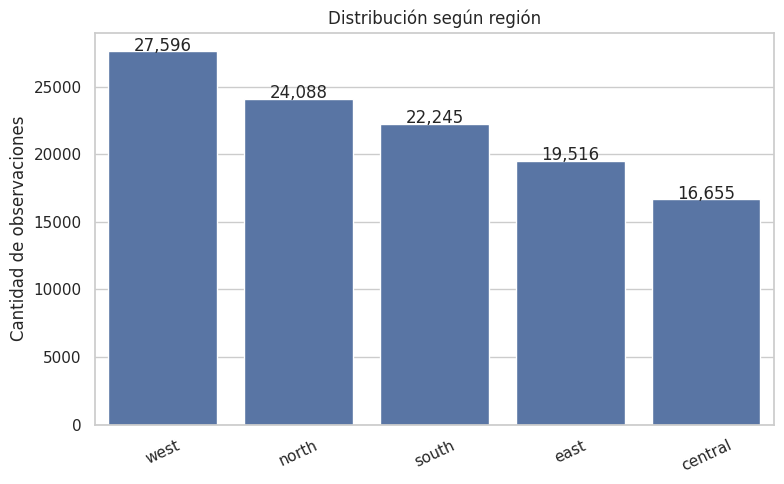

In [70]:
grafico_categoria(
    "region",
    "Distribución según región"
)

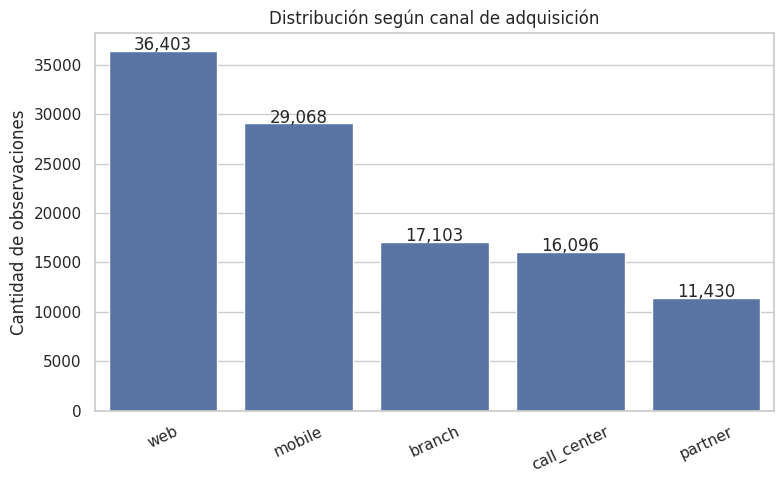

In [71]:
grafico_categoria(
    "canal_adquisicion",
    "Distribución según canal de adquisición"
)

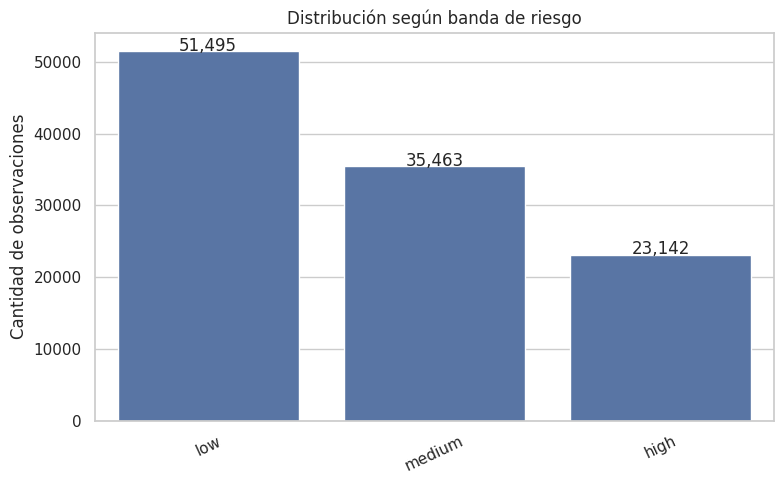

In [72]:
grafico_categoria(
    "banda_riesgo",
    "Distribución según banda de riesgo"
)

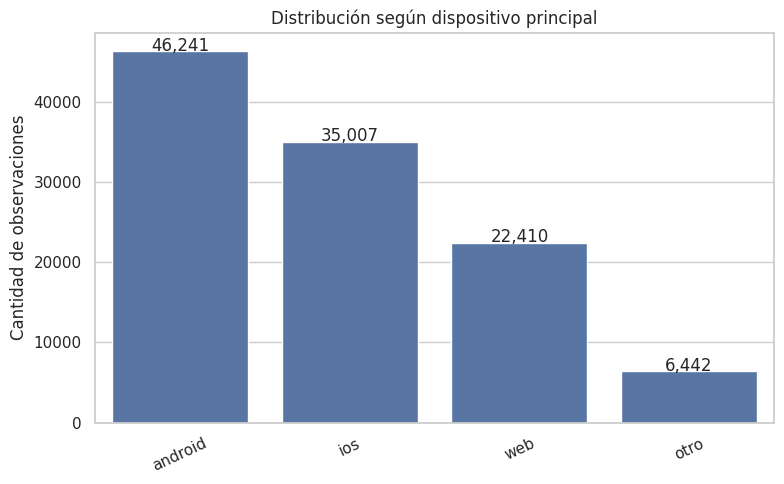

In [73]:
grafico_categoria(
    "dispositivo_principal",
    "Distribución según dispositivo principal"
)

**Analisis de boleanos**

In [74]:
variables_booleanas = [
    "tiene_tarjeta_credito",
    "activo_movil",
    "es_nuevo_cliente",
    "tiene_prestamo",
    "tiene_seguro"
]

In [75]:
def grafico_booleana(columna, titulo):

    conteo = df[columna].value_counts().sort_index()

    plt.figure(figsize=(6,4))

    ax = sns.barplot(
        x=conteo.index.astype(str),
        y=conteo.values
    )

    plt.title(titulo)
    plt.xlabel("")
    plt.ylabel("Cantidad de observaciones")

    for i, valor in enumerate(conteo.values):
        ax.text(
            i,
            valor + 100,
            f"{valor:,}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

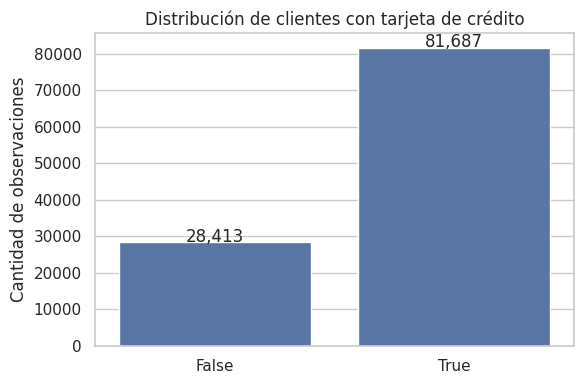

In [76]:
grafico_booleana(
    "tiene_tarjeta_credito",
    "Distribución de clientes con tarjeta de crédito"
)

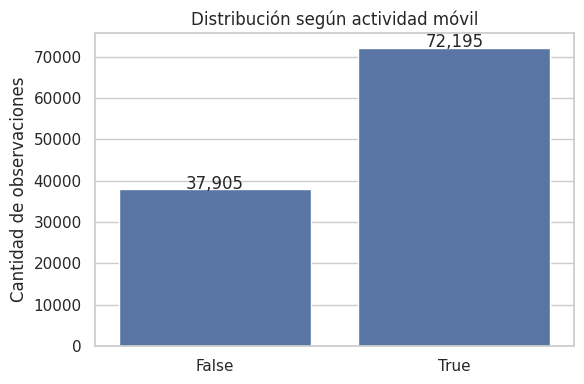

In [77]:
grafico_booleana(
    "activo_movil",
    "Distribución según actividad móvil"
)

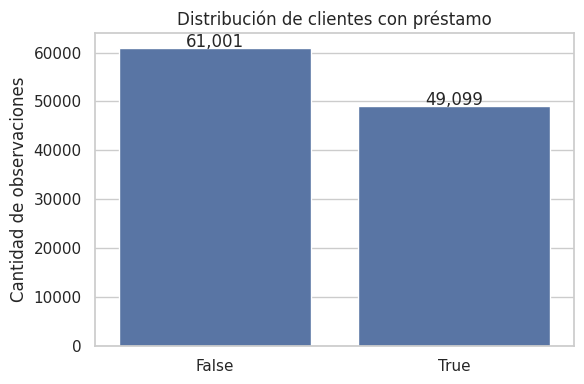

In [78]:
grafico_booleana(
    "tiene_prestamo",
    "Distribución de clientes con préstamo"
)

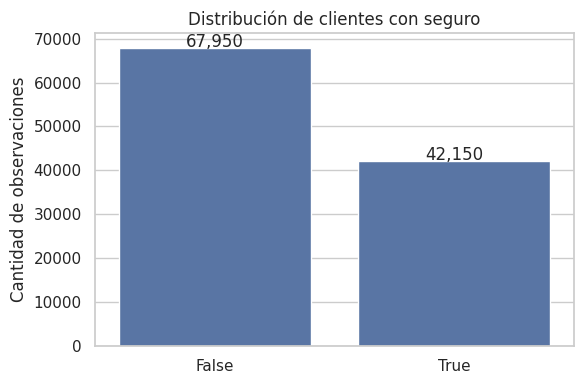

In [79]:
grafico_booleana(
    "tiene_seguro",
    "Distribución de clientes con seguro"
)

**ANALISIS BIVARIADO**

**Categoria vs objetivo**

In [80]:
def conversion_categoria(columna, titulo):

    datos = (
        df.groupby(columna)["objetivo"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index()
    )

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=datos,
        x=columna,
        y="objetivo"
    )

    plt.title(titulo)
    plt.xlabel("")
    plt.ylabel("Tasa de conversión (%)")

    plt.xticks(rotation=25)

    # Porcentaje exacto
    for i, valor in enumerate(datos["objetivo"]):
        ax.text(
            i,
            valor + 0.2,
            f"{valor:.1f}%",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

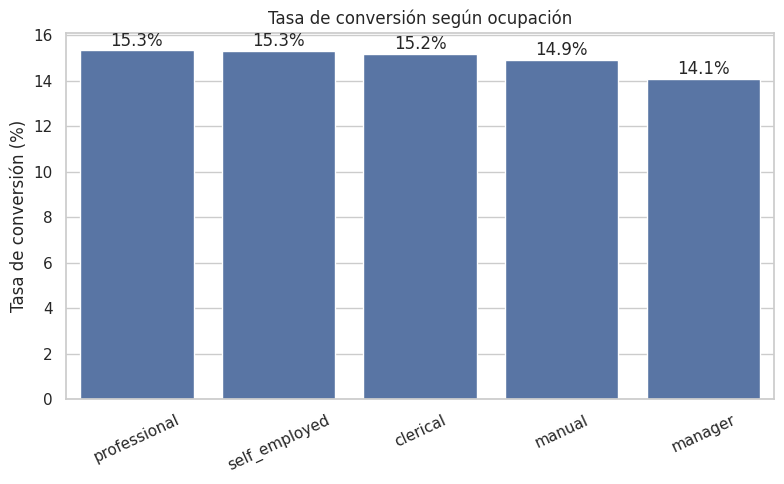

In [81]:
conversion_categoria(
    "ocupacion",
    "Tasa de conversión según ocupación"
)

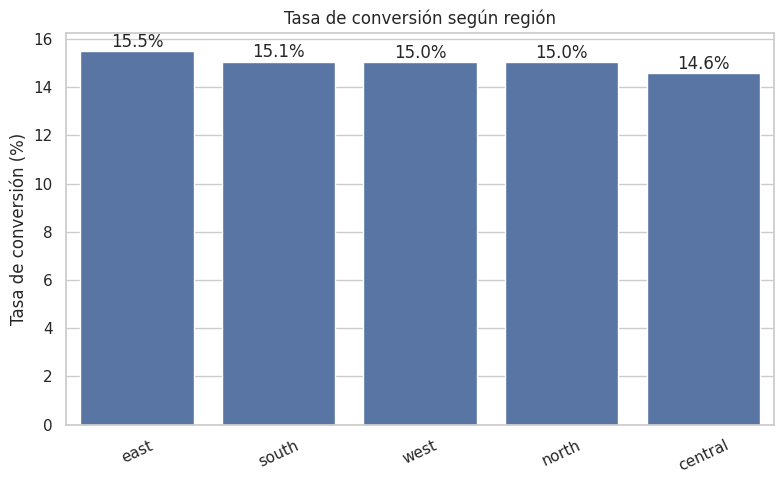

In [82]:
conversion_categoria(
    "region",
    "Tasa de conversión según región"
)

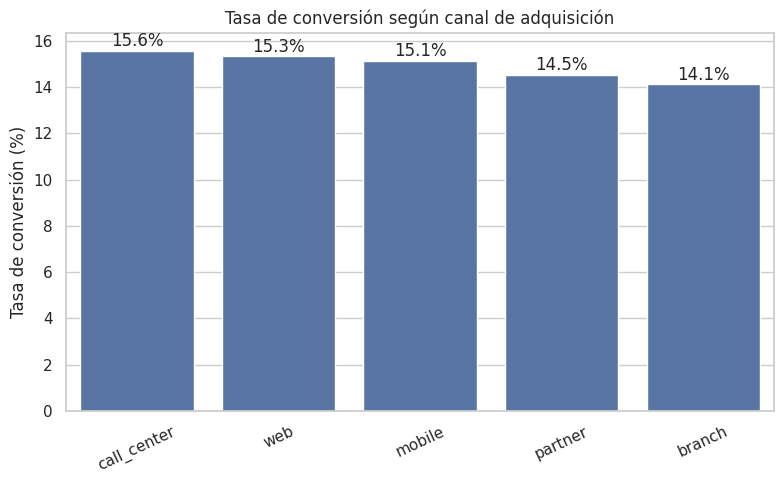

In [83]:
conversion_categoria(
    "canal_adquisicion",
    "Tasa de conversión según canal de adquisición"
)

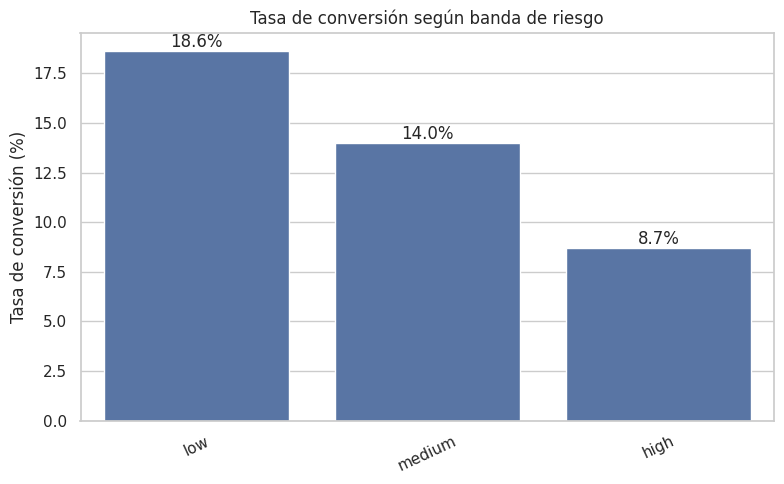

In [84]:
conversion_categoria(
    "banda_riesgo",
    "Tasa de conversión según banda de riesgo"
)

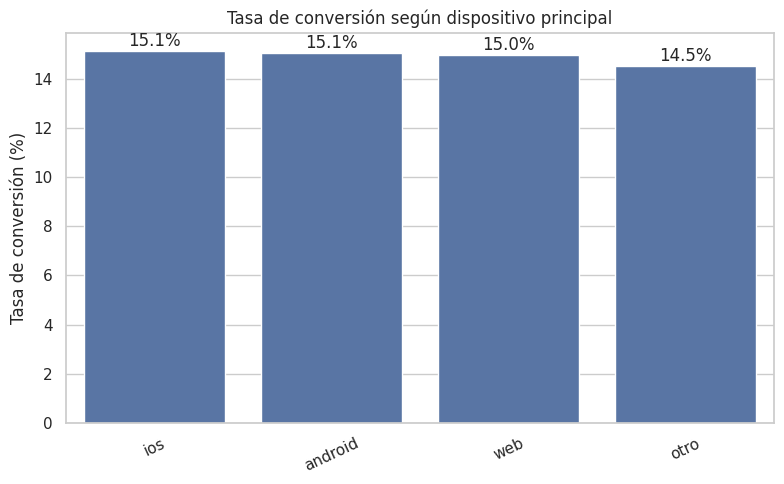

In [85]:
conversion_categoria(
    "dispositivo_principal",
    "Tasa de conversión según dispositivo principal"
)

**Booleanas vs objetivo**

In [86]:
def conversion_booleana(columna, titulo):

    datos = (
        df.groupby(columna)["objetivo"]
          .mean()
          .mul(100)
          .reset_index()
    )

    datos[columna] = datos[columna].map({
        False: "No",
        True: "Sí"
    })

    plt.figure(figsize=(6,5))

    ax = sns.barplot(
        data=datos,
        x=columna,
        y="objetivo"
    )

    plt.title(titulo)
    plt.xlabel("")
    plt.ylabel("Tasa de conversión (%)")

    for i, valor in enumerate(datos["objetivo"]):
        ax.text(
            i,
            valor + 0.2,
            f"{valor:.1f}%",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

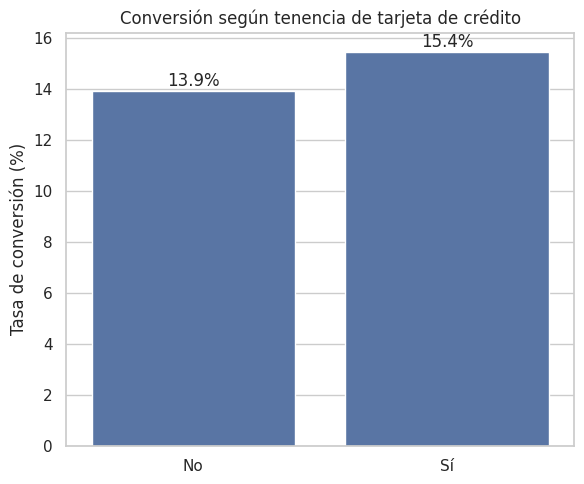

In [87]:
conversion_booleana(
    "tiene_tarjeta_credito",
    "Conversión según tenencia de tarjeta de crédito"
)

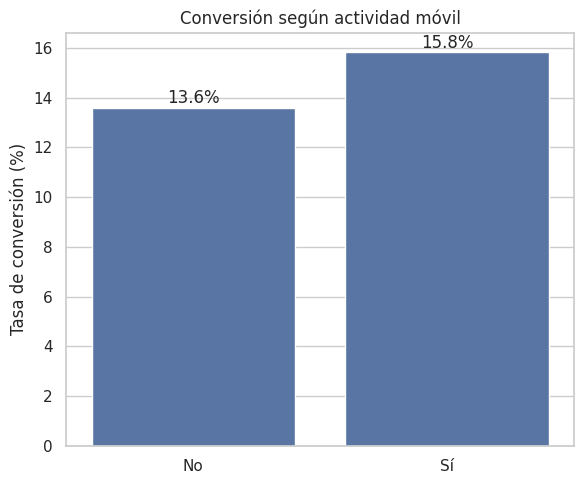

In [88]:
conversion_booleana(
    "activo_movil",
    "Conversión según actividad móvil"
)

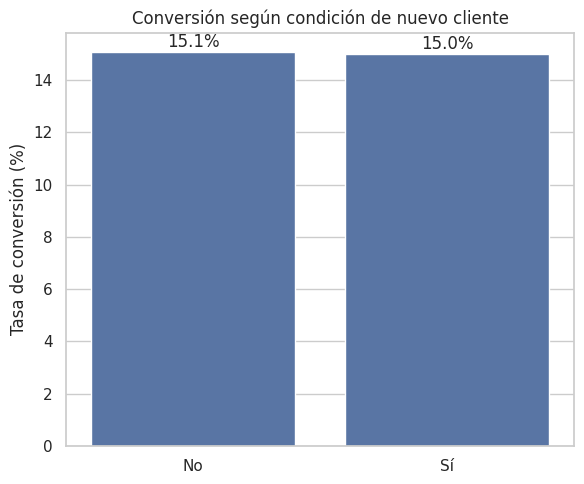

In [89]:
conversion_booleana(
    "es_nuevo_cliente",
    "Conversión según condición de nuevo cliente"
)

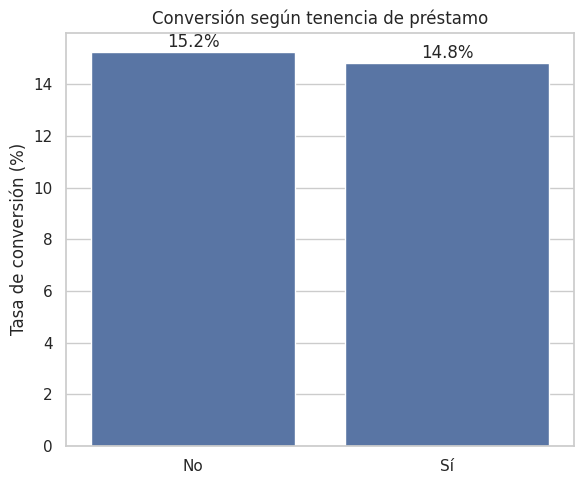

In [90]:
conversion_booleana(
    "tiene_prestamo",
    "Conversión según tenencia de préstamo"
)

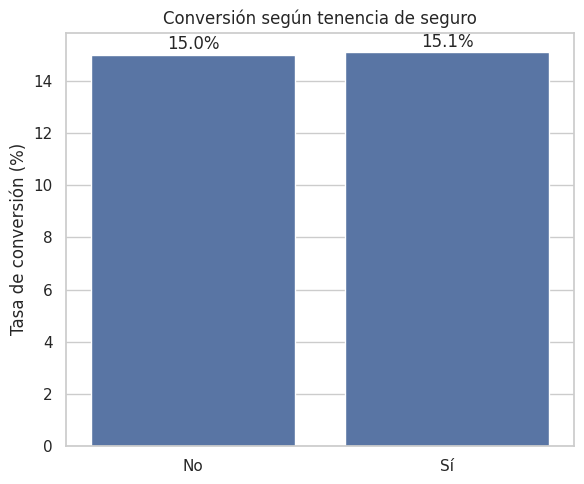

In [91]:
conversion_booleana(
    "tiene_seguro",
    "Conversión según tenencia de seguro"
)

**NUMERICO VS OBJETIVO**

**Ingreso vs convencion**

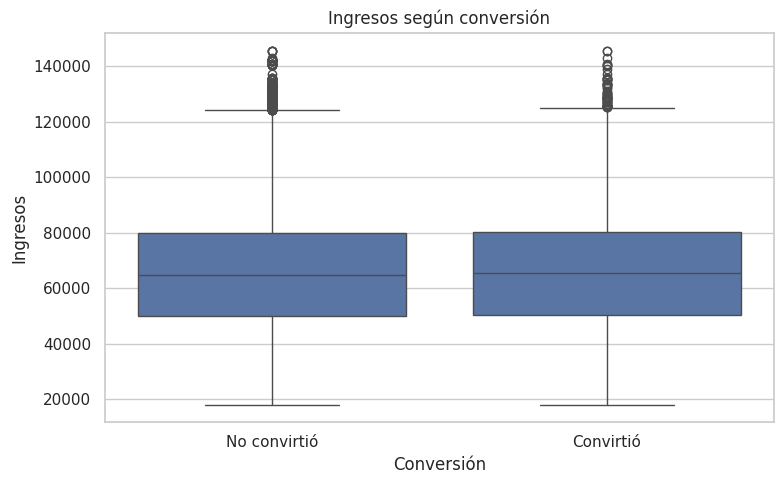

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="objetivo",
    y="ingresos"
)

plt.title("Ingresos según conversión")
plt.xlabel("Conversión")
plt.ylabel("Ingresos")

plt.xticks(
    [0,1],
    ["No convirtió", "Convirtió"]
)

plt.tight_layout()
plt.show()

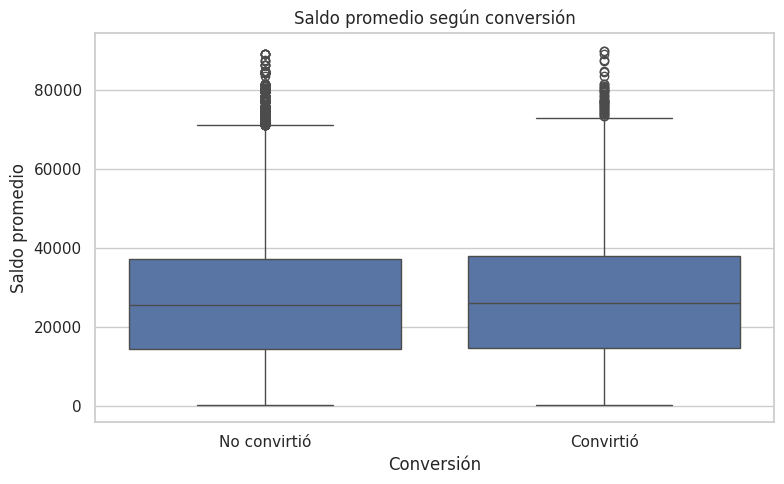

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="objetivo",
    y="saldo_promedio"
)

plt.title("Saldo promedio según conversión")
plt.xlabel("Conversión")
plt.ylabel("Saldo promedio")

plt.xticks(
    [0,1],
    ["No convirtió", "Convirtió"]
)

plt.tight_layout()
plt.show()

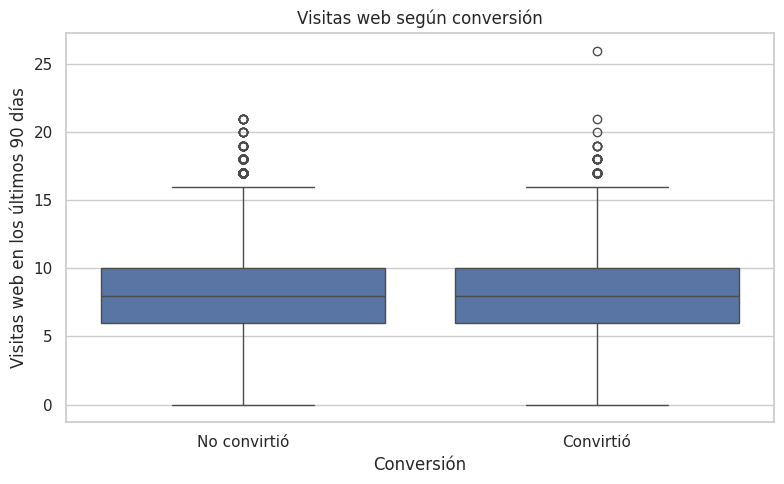

In [94]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="objetivo",
    y="visitas_web_ultimos_90_dias"
)

plt.title("Visitas web según conversión")
plt.xlabel("Conversión")
plt.ylabel("Visitas web en los últimos 90 días")

plt.xticks(
    [0,1],
    ["No convirtió", "Convirtió"]
)

plt.tight_layout()
plt.show()

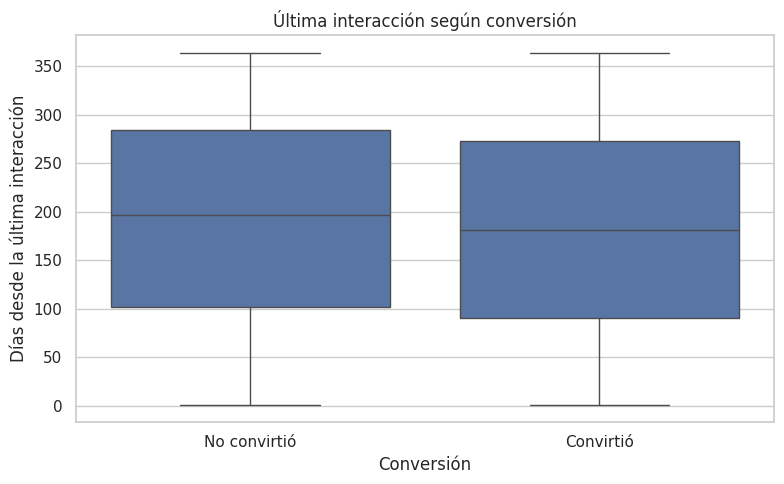

In [95]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="objetivo",
    y="dias_ultima_interaccion"
)

plt.title("Última interacción según conversión")
plt.xlabel("Conversión")
plt.ylabel("Días desde la última interacción")

plt.xticks(
    [0,1],
    ["No convirtió", "Convirtió"]
)

plt.tight_layout()
plt.show()

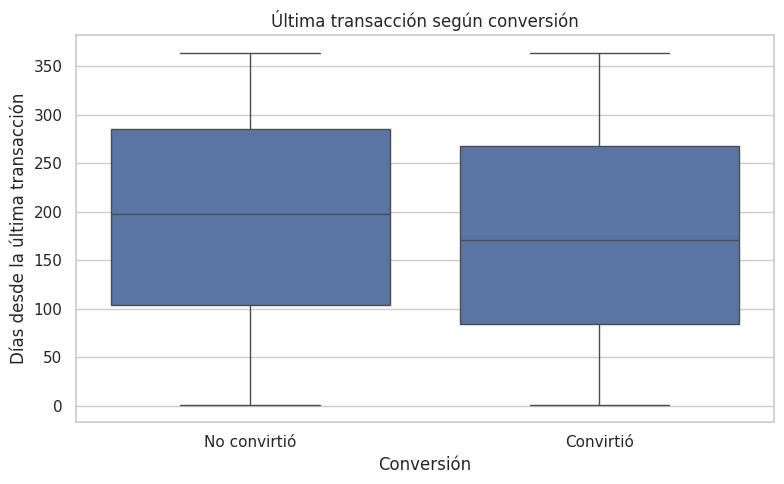

In [96]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="objetivo",
    y="dias_ultima_transaccion"
)

plt.title("Última transacción según conversión")
plt.xlabel("Conversión")
plt.ylabel("Días desde la última transacción")

plt.xticks(
    [0,1],
    ["No convirtió", "Convirtió"]
)

plt.tight_layout()
plt.show()

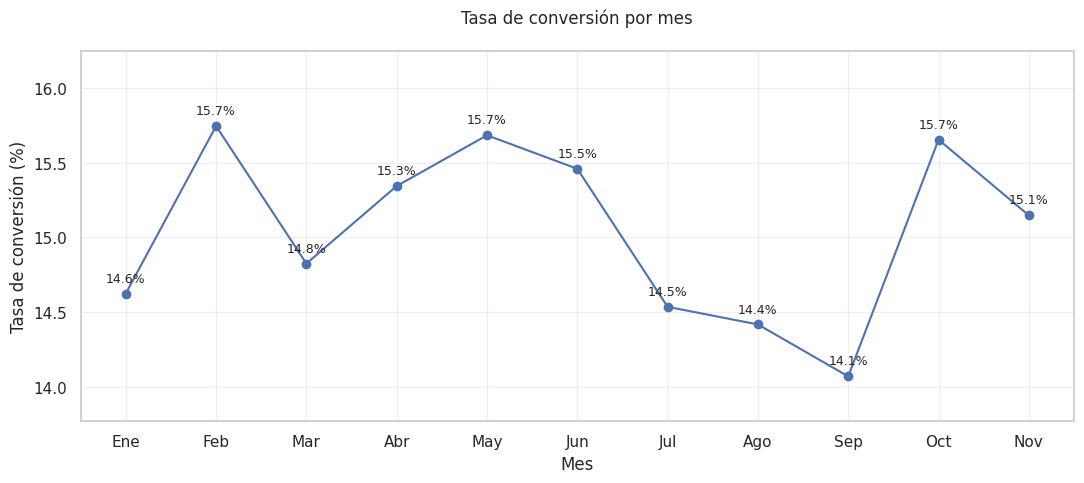

In [98]:
# Calcular tasa de conversión por mes
conversion_mes = (
    df.groupby("mes")["objetivo"]
      .mean()
      .mul(100)
      .reset_index()
)

# Crear etiquetas de mes entendibles
nombres_meses = {
    202601: "Ene",
    202602: "Feb",
    202603: "Mar",
    202604: "Abr",
    202605: "May",
    202606: "Jun",
    202607: "Jul",
    202608: "Ago",
    202609: "Sep",
    202610: "Oct",
    202611: "Nov"
}

conversion_mes["mes_nombre"] = conversion_mes["mes"].map(nombres_meses)

# Gráfico
plt.figure(figsize=(11,5))

plt.plot(
    conversion_mes["mes_nombre"],
    conversion_mes["objetivo"],
    marker="o"
)

plt.title("Tasa de conversión por mes", pad=20)
plt.xlabel("Mes")
plt.ylabel("Tasa de conversión (%)")

# Mostrar porcentaje exacto
for x, y in zip(
    conversion_mes["mes_nombre"],
    conversion_mes["objetivo"]
):
    plt.text(
        x,
        y + 0.08,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

plt.ylim(
    conversion_mes["objetivo"].min() - 0.3,
    conversion_mes["objetivo"].max() + 0.5
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()